In [1]:
import json
import random
from collections import Counter
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18

import sys
import zipfile
import shutil
from tqdm import tqdm

In [2]:
SEED = 42
INTEL_IMAGE_SIZE = 224
INTEL_RESIZE_SIZE = 256
IMAGENET_MEAN = (0.485, 0.456, 0.406) # From ImageNet training set; we use use the same preprocessing the model was trained with.
IMAGENET_STD = (0.229, 0.224, 0.225)
INTEL_BATCH_SIZE = 64
INTEL_WEIGHT_DECAY = 1e-4
INTEL_TRAIN_FRACTION = 0.85
TRANSFER_RESULTS_PATH = Path("results/transfer_results.json")
EARLY_STOPPING_PATIENCE = 5
SSL_BACKBONE_PATH = Path("/content/drive/MyDrive/ssl_pretrain/ssl_backbone.pth")
results = {}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

set_seed(SEED)
DEVICE = get_device()
print("Device:", DEVICE)

Device: cuda


## Part 1.1. Load and visualize Intel training samples

In [3]:
DRIVE_ZIP = Path("/content/drive/MyDrive/Intel Image Classification-1.zip")
LOCAL_ZIP = Path("Intel Image Classification-1.zip")
EXTRACT_DIR = Path("intel_data")


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

# Define the paths based on my observation
INTEL_TRAIN_DIR = EXTRACT_DIR / "seg_train" / "seg_train"
INTEL_TEST_DIR = EXTRACT_DIR / "seg_test" / "seg_test"

if not INTEL_TRAIN_DIR.exists():
    print("Extracting data...")
    EXTRACT_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(DRIVE_ZIP) as archive:
        archive.extractall(EXTRACT_DIR)
else:
    print("Data already extracted.")

print("Train folder:", INTEL_TRAIN_DIR)
print("Test folder:", INTEL_TEST_DIR)

Extracting data...
Train folder: intel_data/seg_train/seg_train
Test folder: intel_data/seg_test/seg_test


In [6]:
intel_train_raw = ImageFolder(INTEL_TRAIN_DIR)
counts = Counter(intel_train_raw.targets)
print("Intel training class counts:")
for index, name in enumerate(intel_train_raw.classes):
    print(f"  {name}: {counts[index]}")
print("Total training-folder images:", len(intel_train_raw))
print("Counts are close (about 2.2k-2.5k), so the dataset is nearly balanced.")

Intel training class counts:
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382
Total training-folder images: 14034
Counts are close (about 2.2k-2.5k), so the dataset is nearly balanced.


Counts are close (about 2.2k-2.5k), so the dataset is nearly balanced.

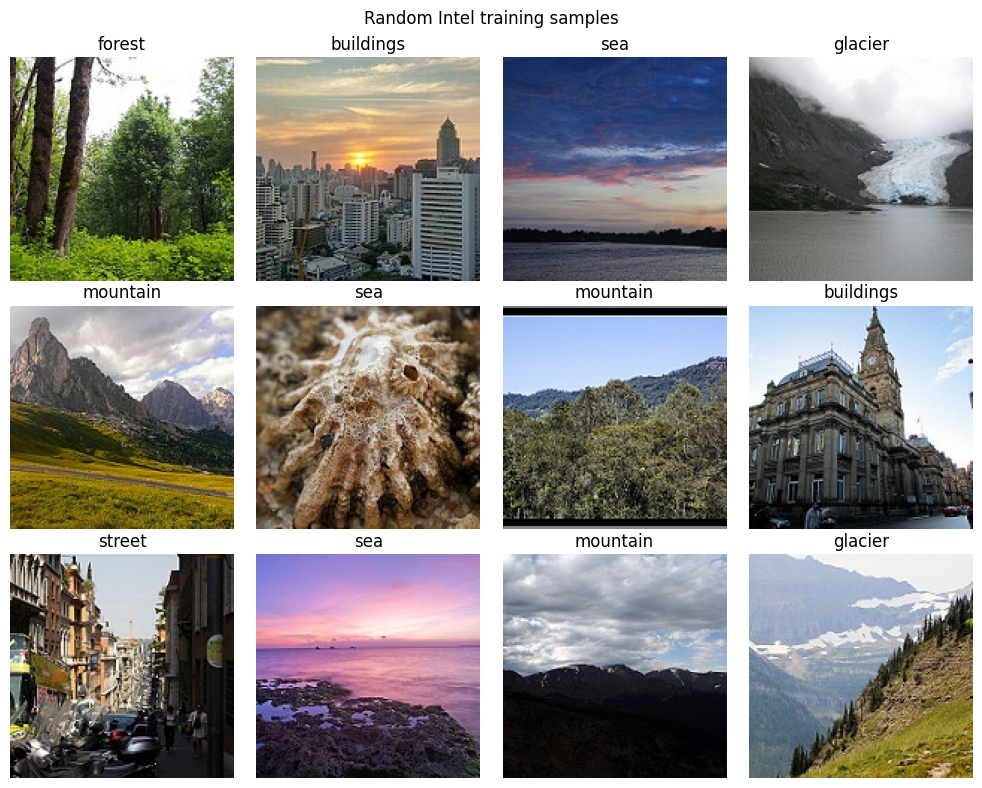

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
rng = torch.Generator().manual_seed(SEED)
choices = torch.randint(0, len(intel_train_raw), (12,), generator=rng)
for axis, index in zip(axes.ravel(), choices.tolist()):
    image, label = intel_train_raw[index]
    axis.imshow(image)
    axis.set_title(intel_train_raw.classes[label])
    axis.axis("off")
fig.suptitle("Random Intel training samples")
fig.tight_layout()

# Ensure the figures directory exists
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/intel_samples.png", dpi=200, bbox_inches="tight")
plt.show()

## Part 1.2: Create Intel Train, Validation, and Test Dataloaders

We split the official training folder with an 85% / 15% train/validation
ratio and seed 42. That is about 12,000 train and 2,000 validation images.

In [8]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]
        return self.transform(image), label

In [9]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(INTEL_IMAGE_SIZE, scale=(0.7, 1.0)), #  training crop scale is random crop from 0.7 to 1.0
    # I use 0.7 here so mountain can still be visible
    transforms.RandomHorizontalFlip(), # flip the image left–right, with 50% probability
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(INTEL_RESIZE_SIZE),
    transforms.CenterCrop(INTEL_IMAGE_SIZE), #  take the middle 224×224 square
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [10]:
generator = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(intel_train_raw), generator=generator)

n_train = int(INTEL_TRAIN_FRACTION * len(intel_train_raw))
train_idx = perm[:n_train].tolist()
val_idx = perm[n_train:].tolist()

intel_train = TransformSubset(Subset(intel_train_raw, train_idx), train_tf)
intel_val = TransformSubset(Subset(intel_train_raw, val_idx), eval_tf)
intel_test = ImageFolder(INTEL_TEST_DIR, transform=eval_tf)

loader_kwargs = {"batch_size": INTEL_BATCH_SIZE, "num_workers": 0}

intel_train_loader = DataLoader(intel_train, shuffle=True, **loader_kwargs)
intel_val_loader = DataLoader(intel_val, shuffle=False, **loader_kwargs)
intel_test_loader = DataLoader(intel_test, shuffle=False, **loader_kwargs)

print(f"{100*INTEL_TRAIN_FRACTION:.0f}%/{100*(1-INTEL_TRAIN_FRACTION):.0f}% split: train {len(intel_train)}, val {len(intel_val)}, test {len(intel_test)}")


85%/15% split: train 11928, val 2106, test 3000


In [11]:
intel_image, intel_label = intel_train[0]
train_batch, train_y = next(iter(intel_train_loader))
val_batch, _ = next(iter(intel_val_loader))
test_batch, _ = next(iter(intel_test_loader))
print("Intel train / val / test lengths:", len(intel_train), len(intel_val), len(intel_test))
print("One Intel image tensor shape:", tuple(intel_image.shape))
print("One example Intel label:", int(intel_label), intel_train_raw.classes[int(intel_label)])
print("Batch shapes:", tuple(train_batch.shape), tuple(val_batch.shape), tuple(test_batch.shape))


Intel train / val / test lengths: 11928 2106 3000
One Intel image tensor shape: (3, 224, 224)
One example Intel label: 1 forest
Batch shapes: (64, 3, 224, 224) (64, 3, 224, 224) (64, 3, 224, 224)


In [12]:
print("Resize size (eval):", INTEL_RESIZE_SIZE)
print("Crop / model input size:", INTEL_IMAGE_SIZE)
print("Normalization mean:", IMAGENET_MEAN)
print("Normalization std:", IMAGENET_STD)
print("Batch size:", INTEL_BATCH_SIZE)
print("Train augmentation: yes (RandomResizedCrop scale=(0.7, 1.0), RandomHorizontalFlip)")
print("Val/test augmentation: no (deterministic Resize + CenterCrop)")
print("Train/validation split fraction:", INTEL_TRAIN_FRACTION, "/", round(1 - INTEL_TRAIN_FRACTION, 2))
print("Train/validation/test sizes:", len(intel_train), len(intel_val), len(intel_test))
print("Random seed:", SEED)

Resize size (eval): 256
Crop / model input size: 224
Normalization mean: (0.485, 0.456, 0.406)
Normalization std: (0.229, 0.224, 0.225)
Batch size: 64
Train augmentation: yes (RandomResizedCrop scale=(0.7, 1.0), RandomHorizontalFlip)
Val/test augmentation: no (deterministic Resize + CenterCrop)
Train/validation split fraction: 0.85 / 0.15
Train/validation/test sizes: 11928 2106 3000
Random seed: 42


## Part 3. Shared model and training utilities

All five conditions use the same ResNet-18 backbone and a new 6-way linear
classifier. S0 starts from random weights. I-Frozen and I-FT start from
ImageNet. SSL-Frozen and SSL-FT load ssl_backbone.pth.

In [13]:
CONDITION_HPARAMS = {
    "S0": {"lr": 1e-3, "epochs": 40, "frozen": False, "init": "random"},
    "I-Frozen": {"lr": 1e-3, "epochs": 40, "frozen": True, "init": "imagenet"},
    "I-FT": {"lr": 1e-4, "epochs": 40, "frozen": False, "init": "imagenet"},
    "SSL-Frozen": {"lr": 1e-3, "epochs": 40, "frozen": True, "init": "ssl"},
    "SSL-FT": {"lr": 1e-4, "epochs": 40, "frozen": False, "init": "ssl"},
}

In [14]:
class ClassifierNet(nn.Module):
    def __init__(self, backbone, num_classes, in_features=512):
        # 512 is the size of ResNet-18’s feature vector after the last pooling layer.
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, images):
        return self.classifier(self.backbone(images))

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False

In [15]:
def build_intel_model(init, frozen):
    if init == "imagenet":
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    else:
        backbone = resnet18(weights=None)
    backbone.fc = nn.Identity()
    if init == "ssl":
        state = torch.load(SSL_BACKBONE_PATH, map_location="cpu", weights_only=True)
        backbone.load_state_dict(state, strict=True)
        print("Loaded SSL backbone from", SSL_BACKBONE_PATH)
    model = ClassifierNet(backbone, num_classes=6)
    if frozen:
        model.freeze_backbone()
    return model

In [16]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss_sum += criterion(logits, labels).item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return loss_sum / total, correct / total

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return loss_sum / total, correct / total

In [18]:
def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs, patience):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_state, best_acc, bad = deepcopy(model.state_dict()), -1.0, 0
    for epoch in tqdm(range(1, epochs + 1), desc="train"):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(
            f"epoch {epoch}/{epochs}  "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f}  "
            f"val loss {va_loss:.4f} acc {va_acc:.4f}"
        )
        if va_acc > best_acc:
            best_state, best_acc, bad = deepcopy(model.state_dict()), va_acc, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    history["best_val_acc"] = best_acc
    history["epochs_trained"] = len(history["val_acc"])
    return history

In [19]:
def run_condition(name):
    hparams = CONDITION_HPARAMS[name]
    set_seed(SEED)
    model = build_intel_model(hparams["init"], hparams["frozen"]).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    params = filter(lambda parameter: parameter.requires_grad, model.parameters())
    optimizer = torch.optim.Adam(params, lr=hparams["lr"], weight_decay=INTEL_WEIGHT_DECAY)
    history = fit(
        model, intel_train_loader, intel_val_loader, criterion, optimizer, DEVICE,
        hparams["epochs"], EARLY_STOPPING_PATIENCE,
    )
    _, test_acc = evaluate(model, intel_test_loader, criterion, DEVICE)

    # Ensure output directories exist
    ckpt_dir = Path("checkpoints")
    ckpt_dir.mkdir(exist_ok=True)
    TRANSFER_RESULTS_PATH.parent.mkdir(exist_ok=True)

    ckpt = ckpt_dir / f"{name.replace('-', '_').lower()}.pth"
    torch.save(model.state_dict(), ckpt)
    return model, history, test_acc, hparams

### S0. From-scratch supervised baseline

In [20]:
results = json.loads(TRANSFER_RESULTS_PATH.read_text()) if TRANSFER_RESULTS_PATH.exists() else {}
if "S0" not in results:
    _, history, test_acc, hp = run_condition("S0")
    results["S0"] = {**hp, "history": history, "test_acc": test_acc,
                     "best_val_acc": history["best_val_acc"], "epochs_trained": history["epochs_trained"]}
    TRANSFER_RESULTS_PATH.write_text(json.dumps(results, indent=2))
print("S0 frozen?", results["S0"]["frozen"], "| val:", results["S0"]["best_val_acc"], "| test:", results["S0"]["test_acc"])


train:   2%|▎         | 1/40 [01:22<53:34, 82.43s/it]

epoch 1/40  train loss 0.9155 acc 0.6571  val loss 1.0510 acc 0.6553


train:   5%|▌         | 2/40 [02:39<50:15, 79.35s/it]

epoch 2/40  train loss 0.6795 acc 0.7523  val loss 0.6664 acc 0.7450


train:   8%|▊         | 3/40 [03:57<48:26, 78.57s/it]

...

train:  48%|████▊     | 19/40 [24:46<27:25, 78.38s/it]

epoch 19/40  train loss 0.3423 acc 0.8774  val loss 0.4004 acc 0.8599


train:  48%|████▊     | 19/40 [26:05<28:50, 82.39s/it]

epoch 20/40  train loss 0.3283 acc 0.8833  val loss 0.3681 acc 0.8637


S0 frozen? False | val: 0.8732193732193733 | test: 0.8683333333333333


### I-Frozen. ImageNet linear probe

In [21]:
if "I-Frozen" not in results:
    _, history, test_acc, hp = run_condition("I-Frozen")
    results["I-Frozen"] = {**hp, "history": history, "test_acc": test_acc,
                           "best_val_acc": history["best_val_acc"], "epochs_trained": history["epochs_trained"]}
    TRANSFER_RESULTS_PATH.write_text(json.dumps(results, indent=2))
print("I-Frozen frozen?", results["I-Frozen"]["frozen"], "| val:", results["I-Frozen"]["best_val_acc"], "| test:", results["I-Frozen"]["test_acc"])


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s]
train:   2%|▎         | 1/40 [00:55<35:52, 55.20s/it]

epoch 1/40  train loss 0.6228 acc 0.7980  val loss 0.3283 acc 0.8955


train:   5%|▌         | 2/40 [01:49<34:48, 54.96s/it]

epoch 2/40  train loss 0.3317 acc 0.8879  val loss 0.2789 acc 0.9060


...

train:  18%|█▊        | 7/40 [06:25<30:22, 55.22s/it]

epoch 7/40  train loss 0.2555 acc 0.9092  val loss 0.2381 acc 0.9093


train:  18%|█▊        | 7/40 [07:21<34:41, 63.07s/it]

epoch 8/40  train loss 0.2577 acc 0.9053  val loss 0.2488 acc 0.9065


I-Frozen frozen? True | val: 0.9154795821462488 | test: 0.9063333333333333


### I-FT. ImageNet full fine-tuning

In [22]:
if "I-FT" not in results:
    _, history, test_acc, hp = run_condition("I-FT")
    results["I-FT"] = {**hp, "history": history, "test_acc": test_acc,
                       "best_val_acc": history["best_val_acc"], "epochs_trained": history["epochs_trained"]}
    TRANSFER_RESULTS_PATH.write_text(json.dumps(results, indent=2))
print("I-FT frozen?", results["I-FT"]["frozen"], "| val:", results["I-FT"]["best_val_acc"], "| test:", results["I-FT"]["test_acc"])


train:   2%|▎         | 1/40 [01:15<48:59, 75.36s/it]

epoch 1/40  train loss 0.3068 acc 0.8943  val loss 0.1932 acc 0.9330


train:   5%|▌         | 2/40 [02:31<48:07, 76.00s/it]

epoch 2/40  train loss 0.1745 acc 0.9392  val loss 0.1851 acc 0.9359


train:   8%|▊         | 3/40 [03:47<46:41, 75.72s/it]

...

train:  22%|██▎       | 9/40 [11:22<39:11, 75.85s/it]

epoch 9/40  train loss 0.0410 acc 0.9863  val loss 0.2700 acc 0.9316


train:  22%|██▎       | 9/40 [12:38<43:30, 84.22s/it]

epoch 10/40  train loss 0.0380 acc 0.9881  val loss 0.2810 acc 0.9245


I-FT frozen? False | val: 0.9406457739791073 | test: 0.9286666666666666


### SSL-Frozen. Rotation-SSL linear probe

In [23]:
print("SSL checkpoint exists:", SSL_BACKBONE_PATH.exists())
if "SSL-Frozen" not in results:
    _, history, test_acc, hp = run_condition("SSL-Frozen")
    results["SSL-Frozen"] = {**hp, "history": history, "test_acc": test_acc,
                             "best_val_acc": history["best_val_acc"], "epochs_trained": history["epochs_trained"]}
    TRANSFER_RESULTS_PATH.write_text(json.dumps(results, indent=2))
print("SSL-Frozen frozen?", results["SSL-Frozen"]["frozen"], "| val:", results["SSL-Frozen"]["best_val_acc"], "| test:", results["SSL-Frozen"]["test_acc"])


SSL checkpoint exists: True
Loaded SSL backbone from /content/drive/MyDrive/ssl_pretrain/ssl_backbone.pth


train:   2%|▎         | 1/40 [00:56<36:31, 56.18s/it]

epoch 1/40  train loss 1.6606 acc 0.2972  val loss 1.6249 acc 0.3333


train:   5%|▌         | 2/40 [01:51<35:06, 55.42s/it]

epoch 2/40  train loss 1.5877 acc 0.3594  val loss 1.5746 acc 0.3623


...

train:  98%|█████████▊| 39/40 [35:56<00:55, 55.77s/it]

epoch 39/40  train loss 1.0514 acc 0.6485  val loss 1.0253 acc 0.6709


train: 100%|██████████| 40/40 [36:52<00:00, 55.30s/it]

epoch 40/40  train loss 1.0505 acc 0.6467  val loss 1.0208 acc 0.6681


SSL-Frozen frozen? True | val: 0.6709401709401709 | test: 0.6683333333333333


### SSL-FT. Rotation-SSL full fine-tuning

In [24]:
if "SSL-FT" not in results:
    _, history, test_acc, hp = run_condition("SSL-FT")
    results["SSL-FT"] = {**hp, "history": history, "test_acc": test_acc,
                         "best_val_acc": history["best_val_acc"], "epochs_trained": history["epochs_trained"]}
    TRANSFER_RESULTS_PATH.write_text(json.dumps(results, indent=2))
print("SSL-FT frozen?", results["SSL-FT"]["frozen"], "| val:", results["SSL-FT"]["best_val_acc"], "| test:", results["SSL-FT"]["test_acc"])
delta = 100 * (results["SSL-FT"]["test_acc"] - results["S0"]["test_acc"])
print(f"SSL-FT minus S0 test accuracy: {delta:.2f} percentage points")


Loaded SSL backbone from /content/drive/MyDrive/ssl_pretrain/ssl_backbone.pth


train:   2%|▎         | 1/40 [01:16<49:32, 76.21s/it]

epoch 1/40  train loss 0.7262 acc 0.8265  val loss 0.4652 acc 0.8708


train:   5%|▌         | 2/40 [02:31<47:53, 75.61s/it]

epoch 2/40  train loss 0.3769 acc 0.8908  val loss 0.3127 acc 0.9084


...

train:  35%|███▌      | 14/40 [17:41<32:59, 76.14s/it]

epoch 14/40  train loss 0.1296 acc 0.9547  val loss 0.2539 acc 0.9226


train:  35%|███▌      | 14/40 [18:58<35:13, 81.30s/it]

epoch 15/40  train loss 0.1146 acc 0.9622  val loss 0.2642 acc 0.9207


SSL-FT frozen? False | val: 0.9264007597340931 | test: 0.918
SSL-FT minus S0 test accuracy: 4.97 percentage points


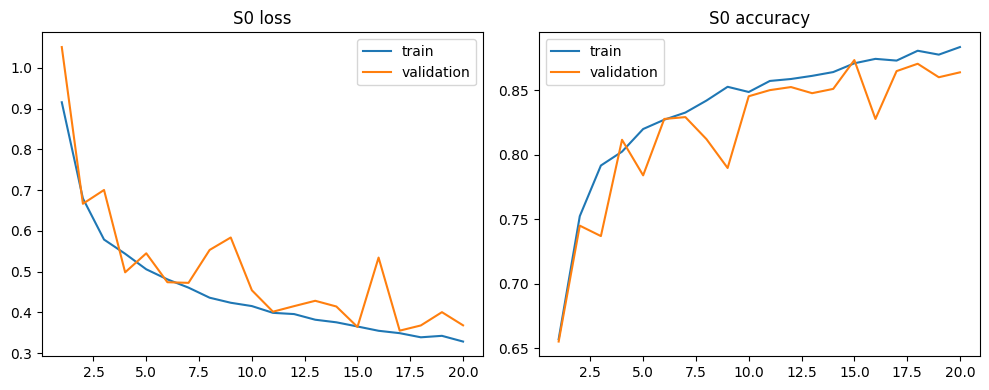

S0 epochs: 20 early stopping: val acc patience 5


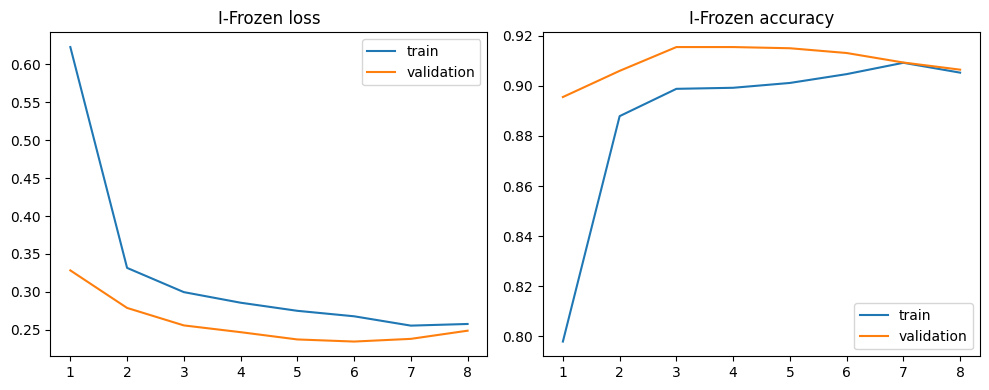

I-Frozen epochs: 8 early stopping: val acc patience 5


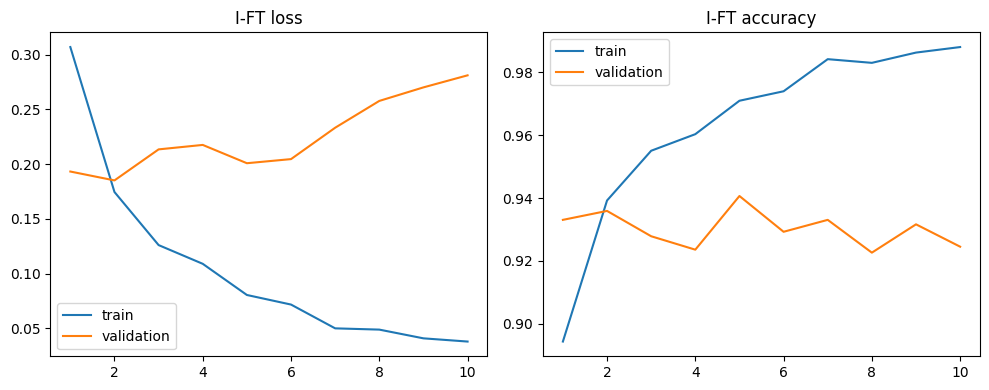

I-FT epochs: 10 early stopping: val acc patience 5


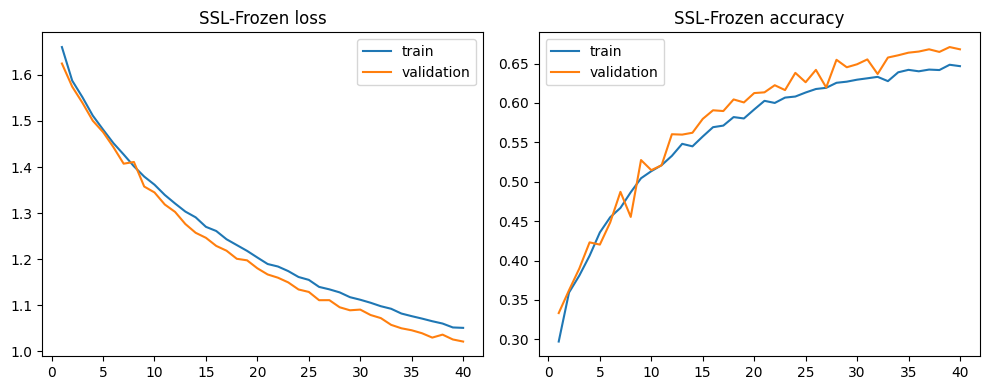

SSL-Frozen epochs: 40 early stopping: val acc patience 5


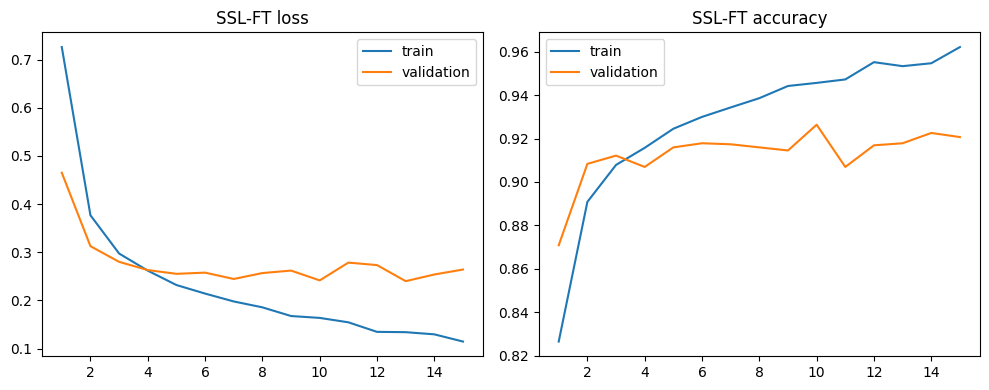

SSL-FT epochs: 15 early stopping: val acc patience 5


In [25]:
def plot_history(history, title, save_path):
    epochs = range(1, len(history["val_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="validation")
    axes[0].set_title(title + " loss")
    axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"], label="validation")
    axes[1].set_title(title + " accuracy")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

for name, payload in results.items():
    plot_history(payload["history"], name, Path("figures") / f"{name}_curves.png")
    print(name, "epochs:", payload["epochs_trained"], "early stopping: val acc patience 5")


In [26]:
def confusion_for(name):
    hparams = CONDITION_HPARAMS[name]
    model = build_intel_model(hparams["init"], hparams["frozen"]).to(DEVICE)
    ckpt = Path("checkpoints") / f"{name.replace('-', '_').lower()}.pth"
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in intel_val_loader:
            y_true.extend(labels.tolist())
            y_pred.extend(model(images.to(DEVICE)).argmax(1).cpu().tolist())
    matrix = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(matrix, display_labels=intel_train_raw.classes).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45
    )
    ax.set_title(name + " validation confusion")
    fig.tight_layout()
    fig.savefig(Path("figures") / f"{name}_confusion.png", dpi=200, bbox_inches="tight")
    plt.show()

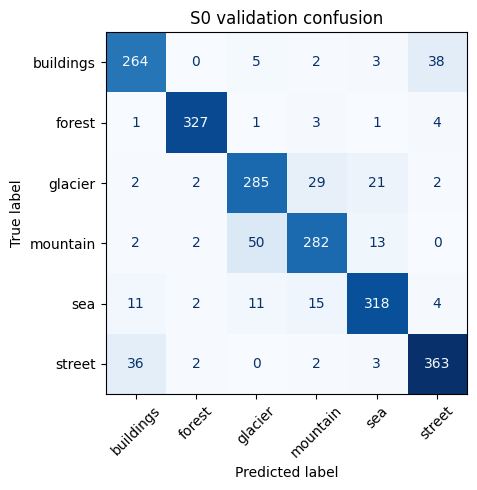

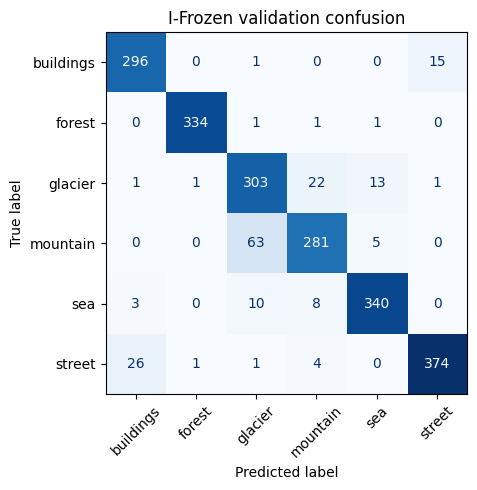

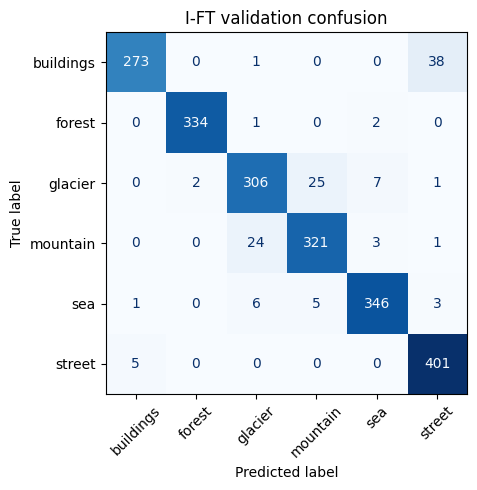

Loaded SSL backbone from /content/drive/MyDrive/ssl_pretrain/ssl_backbone.pth


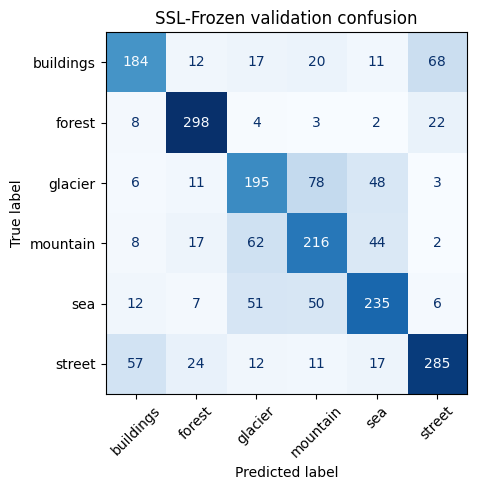

Loaded SSL backbone from /content/drive/MyDrive/ssl_pretrain/ssl_backbone.pth


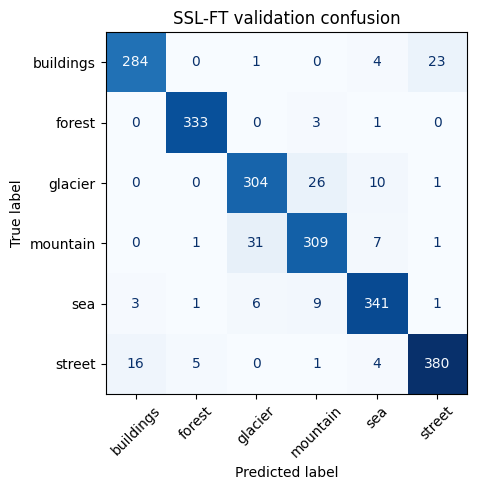

In [27]:
for condition_name in ["S0", "I-Frozen", "I-FT", "SSL-Frozen", "SSL-FT"]:
    ckpt = Path("checkpoints") / f"{condition_name.replace('-', '_').lower()}.pth"
    if ckpt.exists():
        confusion_for(condition_name)
    else:
        print(condition_name, "skipped: missing", ckpt)

 Condition Initialization  Frozen?  Val Accuracy  Test Accuracy  Epochs
        S0         random    False      0.873219       0.868333      20
  I-Frozen       imagenet     True      0.915480       0.906333       8
      I-FT       imagenet    False      0.940646       0.928667      10
SSL-Frozen            ssl     True      0.670940       0.668333      40
    SSL-FT            ssl    False      0.926401       0.918000      15


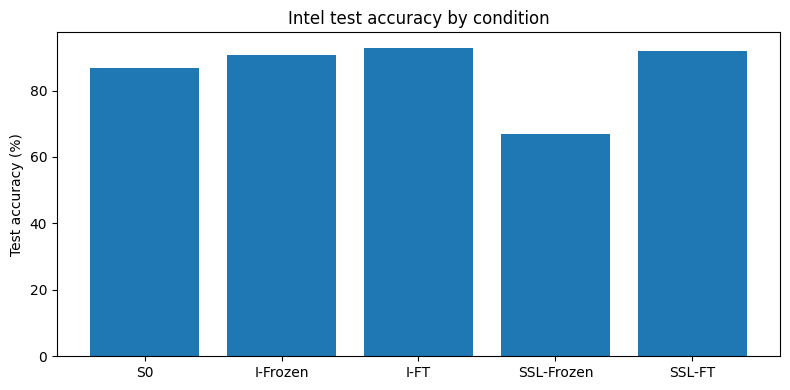

In [28]:
rows = []
for name, payload in results.items():
    rows.append({
        "Condition": name, "Initialization": payload["init"], "Frozen?": payload["frozen"],
        "Val Accuracy": payload["best_val_acc"], "Test Accuracy": payload["test_acc"],
        "Epochs": payload["epochs_trained"],
    })
print(pd.DataFrame(rows).to_string(index=False))
names = list(results)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(names, [100 * results[name]["test_acc"] for name in names])
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Intel test accuracy by condition")
fig.tight_layout()
fig.savefig("figures/test_accuracy_bars.png", dpi=200, bbox_inches="tight")
plt.show()
